# 04 — Engineering the CROT gate with a drive-tuned cross-Kerr interaction

**Where we are in the story.** The spider code failed the Knill–Laflamme test (Notebook 03), so an exotic
primitive is not the way forward. What *every* rotation code needs — cat, binomial or otherwise — is the
teleportation-based error-correction gadget of Grimsmo *et al.* (hybrid Steane–Knill circuit, see
`images/steane_knill_gadget.png`). Its two non-trivial ingredients are a phase measurement on an ancilla and the
controlled-rotation gate

$$\mathrm{CROT}(\varphi) = e^{i\varphi\,\hat n_A\otimes\hat n_B},\qquad \varphi = \frac{2\pi}{K_A K_B}$$

between the data mode ($K_A$-fold symmetric) and the ancilla ($K_B$-fold). On the code space CROT acts as the
identity; a loss of $k$ photons on the data mode becomes a rotation by $-2\pi k/(K_AK_B)$ of the ancilla, which the
phase measurement reads out (`literature/notes/best_state_for_CAN.tex`).

The natural generator of CROT is the **cross-Kerr** interaction $\hat H = \chi_{AB}\,\hat n_A\hat n_B$ between
two superconducting cavities, which they inherit when both are dispersively coupled to a common transmon.
Zhang *et al.* [PRA **105**, 022423 (2022)] showed that an off-resonant drive on the transmon tunes the
cavities' inherited nonlinearities, including through zero. This notebook (i) reproduces that effect,
(ii) extracts the cross-Kerr between two cavities as a function of the drive, and (iii) asks what gate
fidelity the resulting CROT can reach.

## The model

Transmon (Duffing approximation) with $\omega_{10}/2\pi=4.936$ GHz, $\alpha/2\pi=168$ MHz, capacitively coupled
to cavity A (and B), driven off-resonantly. In the frame of the drive and after the RWA,

$$\hat H = -\delta_{da}\hat a^\dagger\hat a - \delta_{dc}\hat c^\dagger\hat c - \tfrac{\alpha}{2}\hat c^\dagger\hat c(\hat c^\dagger\hat c+1)
+ \Omega_d(\hat c+\hat c^\dagger) + g_a(\hat a\hat c^\dagger+\hat a^\dagger\hat c)\ (+\ \text{same for B}).$$

Dimensionless knobs: $r_1=\delta_a/\alpha$, $r_2=g_a/\delta_a\ll1$ (dispersive), $r_3=\delta_d/\alpha$,
$r_4=\Omega_d/\delta_d$. The cavity nonlinearities are read off from the **dressed energy ladder**
$E(N_A,N_B)$ of the eigenstates adiabatically connected to $|N_A,N_B\rangle\otimes|\text{transmon ground}\rangle$:

$$E(N) = E_0+\delta N+\tfrac{K}{2}N^2+\tfrac{\beta}{6}N^3+\dots,\qquad
\chi_{AB}=E(1,1)-E(1,0)-E(0,1)+E(0,0).$$

All frequencies below are ordinary frequencies (GHz, MHz, kHz).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from spiderqec import transmon as tm, rotation_codes as rc, plotting as pl
pl.use_style()
%matplotlib inline

## Step 1 — one cavity: the inherited self-Kerr and its convergence

Baseline of the legacy notebooks: $r_1=9.64,\ r_2=0.064,\ r_3=0.08$, no drive. The legacy value was
$K_A\simeq-2.63$ kHz.

In [2]:
p0 = tm.OneCavityParams(r1=9.64, r2=0.064, r3=0.08, r4=0.0)
print(f"delta_a = {p0.delta_a*1e3:.0f} MHz, g_a = {p0.g_a*1e3:.1f} MHz, delta_d = {p0.delta_d*1e3:.1f} MHz")
print(" dims (cavity, transmon) |   K (kHz) | beta (Hz) | min overlap of labelling")
for dims in [(10, 4), (15, 5), (20, 8), (30, 10)]:
    r = tm.self_kerr(*dims, p0)
    print(f"{str(dims):>24} | {r['K']*1e6:9.4f} | {r['beta']*1e9:9.2f} | {r['min_overlap']:.3f}")

delta_a = 1620 MHz, g_a = 103.6 MHz, delta_d = 13.4 MHz
 dims (cavity, transmon) |   K (kHz) | beta (Hz) | min overlap of labelling
                 (10, 4) |   -2.6219 |      7.57 | 0.980
                 (15, 5) |   -2.6210 |      5.95 | 0.968
                 (20, 8) |   -2.6209 |      5.93 | 0.957
                (30, 10) |   -2.6209 |      5.92 | 0.934


Converged to four digits already at (15, 5): the dispersive regime is kind to truncation.
The "min overlap" column is the smallest overlap between a coupled eigenstate and the bare state it was
labelled with — the sanity check of the adiabatic labelling (it should stay well above 0.5).

## Step 2 — drive-induced nonlinearities (reproducing Zhang *et al.*)

Sweep the drive amplitude $|\Omega_d/\delta_d|^2$ and plot $K$, $\beta$, $\sigma$ normalised to the undriven
$|K^{(0)}|$, in the format of the original paper.

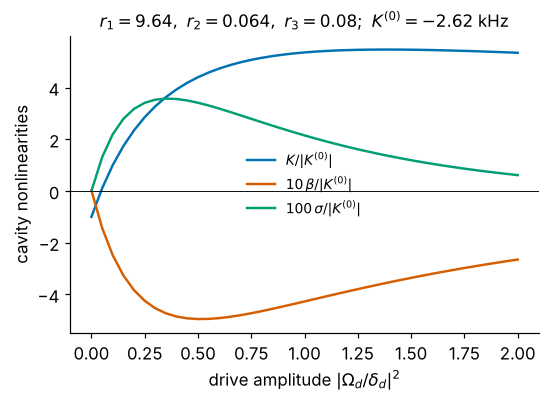

Kerr-free point near |Omega_d/delta_d|^2 = 0.05; maximal |K| = 14.3 kHz at 1.40


In [3]:
r4sq = np.linspace(0, 2.0, 41)
sw = tm.self_kerr_vs_drive(20, 8, r4sq, p0)
K0 = abs(sw["K"][0])
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(r4sq, sw["K"]/K0, label=r"$K/|K^{(0)}|$")
ax.plot(r4sq, 10*sw["beta"]/K0, label=r"$10\,\beta/|K^{(0)}|$")
ax.plot(r4sq, 100*sw["sigma"]/K0, label=r"$100\,\sigma/|K^{(0)}|$")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel(r"drive amplitude $|\Omega_d/\delta_d|^2$"); ax.set_ylabel("cavity nonlinearities"); ax.legend()
ax.set_title(rf"$r_1={p0.r1},\ r_2={p0.r2},\ r_3={p0.r3}$;  $K^{{(0)}}={sw['K'][0]*1e6:.2f}$ kHz")
pl.savefig(fig, "self_kerr_vs_drive_one_cavity", subdir="04_crot_gate")
plt.show()
i0 = np.argmin(np.abs(sw["K"]))
print(f"Kerr-free point near |Omega_d/delta_d|^2 = {r4sq[i0]:.2f}; maximal |K| = {abs(sw['K']).max()*1e6:.1f} kHz at {r4sq[np.argmax(abs(sw['K']))]:.2f}")

The drive flips the sign of the self-Kerr and passes through a **Kerr-free point** — the hallmark of the
drive-induced nonlinearity, here obtained with the simple dressed-ladder fit instead of the perturbative
expressions. (The legacy notebooks also attempted a "pseudo-experimental" extraction by fitting Wigner-function
dynamics, `misc/legacy_notebooks/`; the ladder method is equivalent and $10^3$ times faster.)

## Step 3 — two cavities sharing one transmon: the cross-Kerr

Cavity B is placed on the other side of the transmon ($r_{1b}=-9$) with $r_{2b}=0.05$; the drive detuning is
$r_3=0.26$ as in the legacy three-mode notebook.

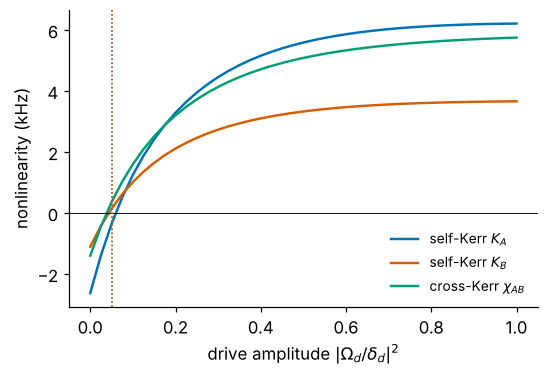

undriven:  K_A=-2.63 kHz, K_B=-1.11 kHz, chi_AB=-1.40 kHz
K_A = 0 at r4^2 = 0.050 where chi_AB = 0.35 kHz and K_B = 0.14 kHz
K_B = 0 at r4^2 = 0.050 where chi_AB = 0.35 kHz and K_A = -0.36 kHz
strong drive: chi_AB -> 5.75 kHz  (x4.1 enhancement in magnitude)


In [4]:
q0 = tm.TwoCavityParams(r1a=9.64, r2a=0.064, r1b=-9.0, r2b=0.05, r3=0.26, r4=0.0)
r4sq2 = np.linspace(0, 1.0, 41)
sw2 = tm.kerr_matrix_vs_drive(8, 8, 6, r4sq2, q0)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(r4sq2, sw2["K_A"]*1e6, label="self-Kerr $K_A$")
ax.plot(r4sq2, sw2["K_B"]*1e6, label="self-Kerr $K_B$")
ax.plot(r4sq2, sw2["chi_AB"]*1e6, label=r"cross-Kerr $\chi_{AB}$")
ax.axhline(0, color="k", lw=0.6)
iA = np.argmin(np.abs(sw2["K_A"])); iB = np.argmin(np.abs(sw2["K_B"]))
ax.axvline(r4sq2[iA], color="C0", ls=":", lw=1); ax.axvline(r4sq2[iB], color="C1", ls=":", lw=1)
ax.set_xlabel(r"drive amplitude $|\Omega_d/\delta_d|^2$"); ax.set_ylabel("nonlinearity (kHz)"); ax.legend()
pl.savefig(fig, "cross_kerr_vs_drive_two_cavities", subdir="04_crot_gate")
plt.show()
print(f"undriven:  K_A={sw2['K_A'][0]*1e6:.2f} kHz, K_B={sw2['K_B'][0]*1e6:.2f} kHz, chi_AB={sw2['chi_AB'][0]*1e6:.2f} kHz")
print(f"K_A = 0 at r4^2 = {r4sq2[iA]:.3f} where chi_AB = {sw2['chi_AB'][iA]*1e6:.2f} kHz and K_B = {sw2['K_B'][iA]*1e6:.2f} kHz")
print(f"K_B = 0 at r4^2 = {r4sq2[iB]:.3f} where chi_AB = {sw2['chi_AB'][iB]*1e6:.2f} kHz and K_A = {sw2['K_A'][iB]*1e6:.2f} kHz")
print(f"strong drive: chi_AB -> {sw2['chi_AB'][-1]*1e6:.2f} kHz  (x{sw2['chi_AB'][-1]/abs(sw2['chi_AB'][0]):.1f} enhancement in magnitude)")
np.save("../data/cross_kerr_vs_drive_two_cavities.npy", np.vstack([r4sq2, sw2["K_A"], sw2["K_B"], sw2["chi_AB"]]))

Three facts the CROT design has to live with:

* The drive enhances $|\chi_{AB}|$ several-fold — good, the gate gets faster.
* The two self-Kerrs and the cross-Kerr all change sign at *nearby but different* drive amplitudes: with one
  transmon and one drive you can null **one** self-Kerr, not both, and not at the maximum of $\chi_{AB}$.
* Everywhere, $|K_A|,|K_B|\sim|\chi_{AB}|$: the unwanted self-phase accumulates as fast as the wanted
  cross-phase.

## Step 4 — the legacy four-mode study (data only)

The original project went one step further and simulated the chain A – q$_c$ – B – q$_b$ (two cavities, two
transmons, two drives), the idea being to null $K_B$ with the second transmon's drive while the first drive
enhances $\chi_{AB}$. Those sweeps took days and only their results survived (`data/legacy/SAB_*.npy`); we
plot them here exactly as the legacy `sab_plot.ipynb` did.

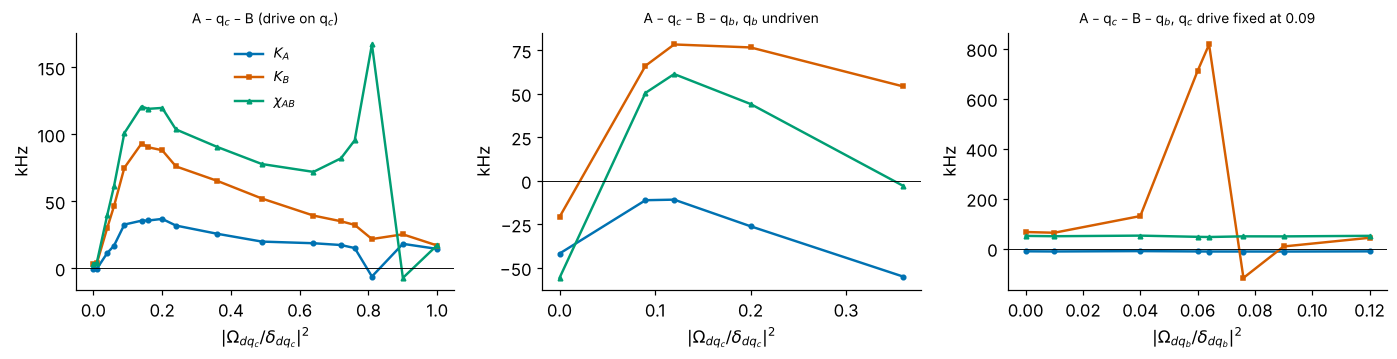

legacy result: with q_c drive 0.09, K_B crosses zero at q_b drive ~ 0.074, where chi_AB ~ 48.4 kHz and K_A ~ -12.0 kHz


In [5]:
AqcB = np.load("../data/legacy/SAB_plots_AqcB.npy")
AqcBqb_qb0 = np.load("../data/legacy/SAB_plots_AqcBqb_qb=0.npy")
AqcBqb_qc009 = np.load("../data/legacy/SAB_plots_AqcBqb_qc=0.09.npy")
kHz = 1e6
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, dat, title, xl in [(axes[0], AqcB, "A – q$_c$ – B (drive on q$_c$)", r"$|\Omega_{dq_c}/\delta_{dq_c}|^2$"),
                           (axes[1], AqcBqb_qb0, "A – q$_c$ – B – q$_b$, q$_b$ undriven", r"$|\Omega_{dq_c}/\delta_{dq_c}|^2$"),
                           (axes[2], AqcBqb_qc009, "A – q$_c$ – B – q$_b$, q$_c$ drive fixed at 0.09", r"$|\Omega_{dq_b}/\delta_{dq_b}|^2$")]:
    ax.plot(dat[0], dat[1]*kHz, "o-", ms=3, label="$K_A$")
    ax.plot(dat[0], dat[2]*kHz, "s-", ms=3, label="$K_B$")
    ax.plot(dat[0], dat[3]*kHz, "^-", ms=3, label=r"$\chi_{AB}$")
    ax.axhline(0, color="k", lw=0.6); ax.set_title(title, fontsize=9); ax.set_xlabel(xl); ax.set_ylabel("kHz")
axes[0].legend()
fig.tight_layout()
pl.savefig(fig, "legacy_four_mode_kerr_chain", subdir="04_crot_gate")
plt.show()
x, KB = AqcBqb_qc009[0], AqcBqb_qc009[2]
i = np.argmax(np.diff(np.sign(KB)) != 0)              # first sign change of K_B
x0 = x[i] - KB[i]*(x[i+1]-x[i])/(KB[i+1]-KB[i])        # linear interpolation of the zero crossing
print(f"legacy result: with q_c drive 0.09, K_B crosses zero at q_b drive ~ {x0:.3f}, where chi_AB ~ {np.interp(x0, x, AqcBqb_qc009[3])*kHz:.1f} kHz and K_A ~ {np.interp(x0, x, AqcBqb_qc009[1])*kHz:.1f} kHz")

(The legacy parameter set differs from Step 3 — a different transmon, $\alpha/2\pi=125$ MHz, and larger
couplings — hence the larger absolute numbers.) The two-transmon chain does provide an operating point with
$K_B\simeq0$ and a cross-Kerr of $\sim50$ kHz, at the price of a residual $K_A\approx-12$ kHz. One transmon per
self-Kerr to be cancelled: that is the design rule this study arrived at.

## Step 5 — what CROT fidelity does this buy?

Target gate: $\varphi=2\pi/(K_AK_B)=2\pi/9$ between an order-3 binomial data code ($L=4$, the KL-correct code
of Notebook 03) and an order-3 cat ancilla ($\alpha=2$). The gate is generated by
$\hat H_{\rm eff}=\chi_{AB}\hat n_A\hat n_B+\tfrac{K_A}{2}\hat n_A^2+\tfrac{K_B}{2}\hat n_B^2$ for the time
$t_g=|\varphi|/(2\pi|\chi_{AB}|)$; we compare it with the ideal CROT on the 4-dimensional logical subspace via the
average gate fidelity (leakage counts as error). Linear terms are absorbed in the rotating frames.

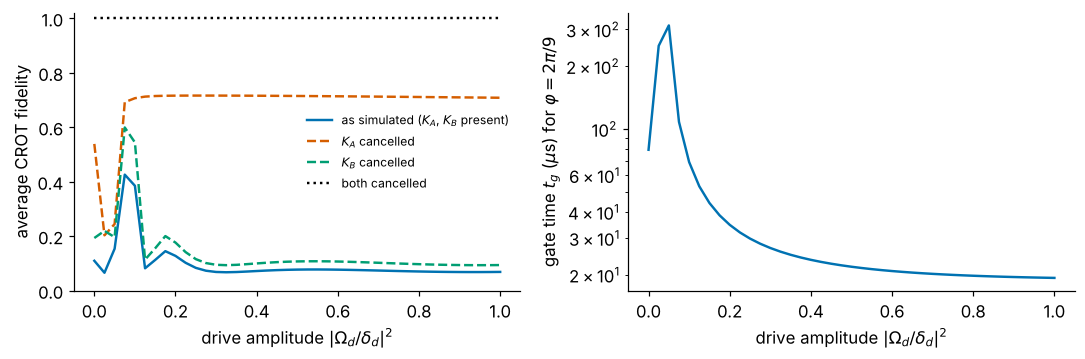

gate time at strongest drive: 19.3 us  (chi = 5.75 kHz)
fidelity with self-Kerr present: 0.065 - 0.426;  with both self-Kerrs cancelled: 1.000000


In [6]:
Nf = 40
zA, oA = rc.codewords_from_plus(rc.binomial_plus(3, 4, Nf), 3)
zB, oB = rc.codewords_from_plus(rc.cat_plus(3, 2.0, Nf), 3)
basis = tm.logical_two_qubit_basis(zA, oA, zB, oB)
phi = 2*np.pi/9

def crot_fidelity(chi, KA, KB):
    t_g = phi/(2*np.pi*abs(chi))
    U_ideal = tm.crot(-np.sign(chi)*phi, Nf, Nf)          # sign of the angle follows the sign of chi
    U = tm.kerr_unitary(t_g, chi, KA, KB, Nf, Nf)
    return t_g, tm.average_gate_fidelity(U_ideal, U, basis)

tg = np.array([crot_fidelity(c, a, b)[0] for c, a, b in zip(sw2["chi_AB"], sw2["K_A"], sw2["K_B"])])
F_full = np.array([crot_fidelity(c, a, b)[1] for c, a, b in zip(sw2["chi_AB"], sw2["K_A"], sw2["K_B"])])
F_noKA = np.array([crot_fidelity(c, 0, b)[1] for c, a, b in zip(sw2["chi_AB"], sw2["K_A"], sw2["K_B"])])
F_noKB = np.array([crot_fidelity(c, a, 0)[1] for c, a, b in zip(sw2["chi_AB"], sw2["K_A"], sw2["K_B"])])
F_none = np.array([crot_fidelity(c, 0, 0)[1] for c in sw2["chi_AB"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
ax = axes[0]
ax.plot(r4sq2, F_full, label="as simulated ($K_A$, $K_B$ present)")
ax.plot(r4sq2, F_noKA, "--", label="$K_A$ cancelled")
ax.plot(r4sq2, F_noKB, "--", label="$K_B$ cancelled")
ax.plot(r4sq2, F_none, "k:", label="both cancelled")
ax.set_xlabel(r"drive amplitude $|\Omega_d/\delta_d|^2$"); ax.set_ylabel("average CROT fidelity"); ax.set_ylim(0, 1.02); ax.legend(fontsize=8)
ax = axes[1]
ax.plot(r4sq2, tg/1e3)
ax.set_xlabel(r"drive amplitude $|\Omega_d/\delta_d|^2$"); ax.set_ylabel(r"gate time $t_g$ ($\mu$s) for $\varphi=2\pi/9$"); ax.set_yscale("log")
fig.tight_layout()
pl.savefig(fig, "crot_fidelity_and_time_vs_drive", subdir="04_crot_gate")
plt.show()
print(f"gate time at strongest drive: {tg[-1]/1e3:.1f} us  (chi = {sw2['chi_AB'][-1]*1e6:.2f} kHz)")
print(f"fidelity with self-Kerr present: {F_full.min():.3f} - {F_full.max():.3f};  with both self-Kerrs cancelled: {F_none.min():.6f}")

Without self-Kerr the cross-Kerr unitary *is* the CROT (fidelity 1 up to numerical precision, since
$\hat n_A\hat n_B$ is the exact generator). With the self-Kerr the fidelity collapses, even at the point where one of
them is nulled by the drive: over a $\sim20\ \mu$s gate a 5 kHz self-Kerr accumulates phases of order
$\pi\bar n^2$. How small must the residual self-Kerr be?

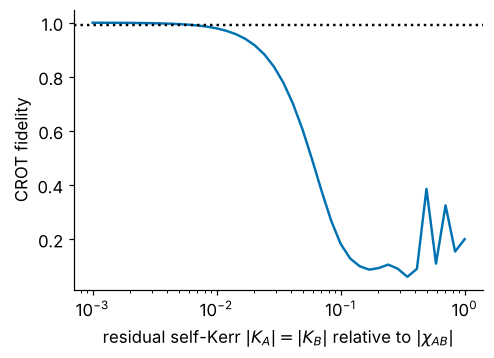

F > 0.99 requires |K| < 0.007 |chi_AB|  (~ 0.04 kHz at chi = 5.8 kHz)


In [7]:
chi = sw2["chi_AB"][-1]
ratios = np.logspace(-3, 0, 40)
F_tol = np.array([crot_fidelity(chi, r*chi, r*chi)[1] for r in ratios])
fig, ax = plt.subplots(figsize=(4.8, 3.3))
ax.semilogx(ratios, F_tol)
ax.axhline(0.99, color="k", ls=":"); ax.set_xlabel(r"residual self-Kerr $|K_A|=|K_B|$ relative to $|\chi_{AB}|$"); ax.set_ylabel("CROT fidelity")
pl.savefig(fig, "crot_fidelity_vs_residual_self_kerr", subdir="04_crot_gate")
plt.show()
r99 = ratios[np.argmax(F_tol < 0.99)]
print(f"F > 0.99 requires |K| < {r99:.3f} |chi_AB|  (~ {r99*abs(chi)*1e6:.2f} kHz at chi = {abs(chi)*1e6:.1f} kHz)")

## Step 6 — the published solution: a *targeted* resonance (Qin *et al.*, 2026)

The original group finished the project after these notebooks were written:
S. Qin, L. D. H. My, A. Copetudo, A. M. Kasper, Y. Y. Gao and H. K. Ng, *Single-tone drive-enhanced CROT gate for
bosonic quantum error correction*, [arXiv:2609.07076](https://arxiv.org/abs/2609.07076). Their resolution of the
self-Kerr problem is not to drive harder, but to drive *smarter*: choose the single-tone drive so that the system
sits next to the two-cavity resonance

$$D^{\rm res}=\omega_a-(\omega_b+\epsilon_{10})\approx 0,$$

i.e. the drive-dressed transmon converts an $a$ photon into a $b$ photon plus one transmon excitation. The
cross-Kerr, which involves both cavities, is resonantly enhanced as $1/D^{\rm res}$, while the self-Kerrs, which
involve only one cavity, are not. Their parameters: $\omega_a/2\pi=4.0$, $\omega_b/2\pi=4.3$,
$\omega_{10}/2\pi=4.65$ GHz, $\alpha/2\pi=0.2$ GHz, $|g_a/\delta_a|=0.04$, $|g_b/\delta_b|=0.03$,
$|\Omega_d/\delta_d|=1$, and the drive detuning $\delta_d/\alpha$ swept up to the resonance (exact numerics put it at
$\delta_d/\alpha\simeq0.88$; their working point is $0.835$). The residual self-Kerr of cavity $a$ is then cancelled
with a driven *side* transmon coupled only to $a$ — exactly the four-mode chain of the legacy data above.

Does the dressed-ladder code reproduce this? We simply feed it their parameters.

undriven: K_A=-0.60 kHz, K_B=-0.22 kHz, chi_AB=-0.71 kHz


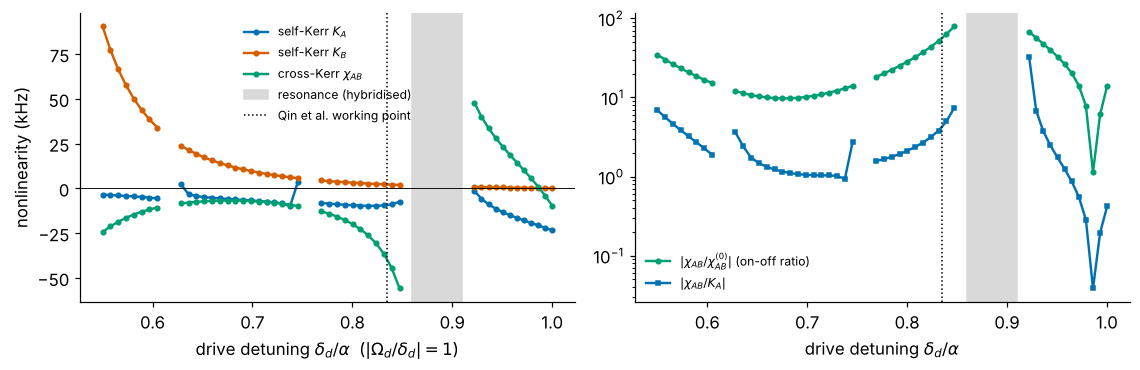

at delta_d/alpha = 0.832: chi_AB = -36.6 kHz (on-off 52),  K_A = -9.6 kHz,  K_B = 2.23 kHz
on the other flank, delta_d/alpha = 0.922: K_A = -1.47 kHz, chi_AB = 47.8 kHz, K_B = 0.72 kHz


In [8]:
tp_qin = tm.TransmonParams(omega10=4.65, alpha=0.2)
q_qin = tm.TwoCavityParams(r1a=(4.0-4.65)/0.2, r2a=0.04, r1b=(4.3-4.65)/0.2, r2b=0.03, r3=0.8, r4=0.0, tp=tp_qin)
undriven = tm.kerr_matrix(8, 8, 8, q_qin)
print(f"undriven: K_A={undriven['K_A']*1e6:.2f} kHz, K_B={undriven['K_B']*1e6:.2f} kHz, chi_AB={undriven['chi_AB']*1e6:.2f} kHz")

r3_list = np.concatenate([np.linspace(0.55, 0.855, 40), np.linspace(0.915, 1.05, 20)])
rows = []
for r3 in r3_list:
    p = tm.TwoCavityParams(q_qin.r1a, q_qin.r2a, q_qin.r1b, q_qin.r2b, r3, 1.0, tp_qin)
    rows.append(tm.kerr_matrix(7, 7, 14, p))
qin = {k: np.array([r[k] for r in rows]) for k in rows[0]}
# inside the resonance window the dressed state |1,0,0> hybridises with |0,1,1>: finite differences of the ladder
# are meaningless there, and the labelling overlap drops.  Mask those points.
ok = (qin["min_overlap"] > 0.93) & (np.abs(qin["K_A"]) < 1e-3)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.5))
ax = axes[0]
for key, lab in [("K_A", "self-Kerr $K_A$"), ("K_B", "self-Kerr $K_B$"), ("chi_AB", r"cross-Kerr $\chi_{AB}$")]:
    ax.plot(r3_list, np.where(ok, qin[key], np.nan)*1e6, "o-", ms=3, label=lab)
ax.axvspan(0.86, 0.91, color="0.85", label="resonance (hybridised)")
ax.axvline(0.835, color="k", ls=":", lw=1, label="Qin et al. working point")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel(r"drive detuning $\delta_d/\alpha$  ($|\Omega_d/\delta_d|=1$)"); ax.set_ylabel("nonlinearity (kHz)"); ax.legend(fontsize=8)
ax = axes[1]
ax.semilogy(r3_list, np.where(ok, np.abs(qin["chi_AB"]/undriven["chi_AB"]), np.nan), "o-", ms=3, color="C2", label=r"$|\chi_{AB}/\chi_{AB}^{(0)}|$ (on-off ratio)")
ax.semilogy(r3_list, np.where(ok, np.abs(qin["chi_AB"]/qin["K_A"]), np.nan), "s-", ms=3, color="C0", label=r"$|\chi_{AB}/K_A|$")
ax.axvspan(0.86, 0.91, color="0.85"); ax.axvline(0.835, color="k", ls=":", lw=1)
ax.set_xlabel(r"drive detuning $\delta_d/\alpha$"); ax.legend(fontsize=8)
fig.tight_layout()
pl.savefig(fig, "qin2026_targeted_resonance_cross_kerr", subdir="04_crot_gate")
plt.show()
i = np.argmin(np.abs(r3_list - 0.835))
print(f"at delta_d/alpha = {r3_list[i]:.3f}: chi_AB = {qin['chi_AB'][i]*1e6:.1f} kHz (on-off {abs(qin['chi_AB'][i]/undriven['chi_AB']):.0f}),  K_A = {qin['K_A'][i]*1e6:.1f} kHz,  K_B = {qin['K_B'][i]*1e6:.2f} kHz")
j = np.where(ok & (r3_list > 0.9))[0][np.argmin(np.abs(qin["K_A"][ok & (r3_list > 0.9)]))]
print(f"on the other flank, delta_d/alpha = {r3_list[j]:.3f}: K_A = {qin['K_A'][j]*1e6:.2f} kHz, chi_AB = {qin['chi_AB'][j]*1e6:.1f} kHz, K_B = {qin['K_B'][j]*1e6:.2f} kHz")
np.save("../data/qin2026_cross_kerr_vs_drive_detuning.npy", np.vstack([r3_list, qin["K_A"], qin["K_B"], qin["chi_AB"], qin["min_overlap"]]))

The dressed-ladder numerics reproduce the published picture without any perturbation theory: approaching the
resonance from below, $|\chi_{AB}|$ grows from $0.7$ kHz to $\sim40$ kHz at their working point (on-off ratio
$\sim55$, their perturbative estimate was $>60$) and to $60$ kHz just before the hybridisation window, while $K_B$
*decreases* towards zero and $K_A$ stays at a few kHz — a ratio $|\chi_{AB}/K_A|\approx4$–$9$ instead of the
$\approx1$ of the untargeted sweep in Step 3. On the far flank of the resonance ($\delta_d/\alpha\simeq0.92$) the
numerics even show a point where $K_A$ itself crosses zero with $\chi_{AB}\simeq50$ kHz; Qin *et al.* stay on the
near flank and remove the residual $K_A$ with the side transmon instead.

What does the residual buy for the gate? We use their error-correction example — order-2 binomial data code and an
order-1 cat ancilla, first CROT angle $\varphi=2\pi/(NM)=\pi$ — and compare the working point with and without the
side-transmon cancellation of $K_A$. Two fidelities are relevant: the two-mode average gate fidelity used above, and
the fidelity of the *data rail* alone, which is what Qin *et al.* quote (the ancilla is measured right after the
gate, so a residual Kerr phase on the ancilla is a calibration of the phase measurement, not a gate error).

In [9]:
zD, oD = rc.codewords_from_plus(rc.binomial_plus(2, 2, Nf), 2)          # N = 2 binomial, nbar = 2
zA, oA = rc.codewords_from_plus(rc.cat_plus(1, np.sqrt(2.0), Nf), 1)     # M = 1 cat (coherent state, nbar = 2)
basis_qin = tm.logical_two_qubit_basis(zD, oD, zA, oA)
phi_qin = np.pi
chi, KA, KB = qin["chi_AB"][i], qin["K_A"][i], qin["K_B"][i]
t_g = phi_qin/(2*np.pi*abs(chi))
U_ideal = tm.crot(-np.sign(chi)*phi_qin, Nf, Nf)
for label, ka, kb in [("as simulated (central transmon only)", KA, KB), ("K_A cancelled by side transmon", 0.0, KB), ("both self-Kerrs cancelled", 0.0, 0.0)]:
    F = tm.average_gate_fidelity(U_ideal, tm.kerr_unitary(t_g, chi, ka, kb, Nf, Nf), basis_qin)
    print(f"{label:40s}  F = {F:.4f}")
print(f"gate time for CROT(pi) at this working point: {t_g/1e3:.1f} us")

# Qin et al. quote the fidelity of the *data rail*.  A residual self-Kerr on the ancilla alone is a unitary on B
# only; it commutes with CROT and cannot change the reduced state of the data mode A.  Check it explicitly:
def data_rail_fidelity(U_act, state):
    out_i = (U_ideal @ state).reshape(Nf, Nf); out_a = (U_act @ state).reshape(Nf, Nf)
    rho_i = out_i @ out_i.conj().T; rho_a = out_a @ out_a.conj().T          # partial trace over the ancilla
    w, v = np.linalg.eigh(rho_i); sq = (v * np.sqrt(np.clip(w, 0, None))) @ v.conj().T
    return float(np.real(np.trace(sq @ rho_a @ sq)) ** 0.5) if False else float(np.real(np.sum(np.sqrt(np.clip(np.linalg.eigvalsh(sq @ rho_a @ sq), 0, None))))**2)
probe = [basis_qin[:, k] for k in range(4)] + [(basis_qin[:, 0] + basis_qin[:, 3]) / np.sqrt(2)]
for label, ka, kb in [("as simulated", KA, KB), ("K_A cancelled by side transmon", 0.0, KB)]:
    U = tm.kerr_unitary(t_g, chi, ka, kb, Nf, Nf)
    print(f"data-rail fidelity, {label:32s}: min over probes = {min(data_rail_fidelity(U, s) for s in probe):.4f}")

as simulated (central transmon only)      F = 0.4273
K_A cancelled by side transmon            F = 0.6859
both self-Kerrs cancelled                 F = 1.0000
gate time for CROT(pi) at this working point: 13.7 us
data-rail fidelity, as simulated                    : min over probes = 0.9778
data-rail fidelity, K_A cancelled by side transmon  : min over probes = 1.0000


**Take-away for the story (revised).** A single-tone drive placed next to the $a\leftrightarrow b$ conversion
resonance enhances the cross-Kerr by nearly two orders of magnitude while leaving the self-Kerrs small; one driven
side transmon removes what is left. With the side transmon cancelling $K_A$, the data rail is untouched by the remaining ancilla self-Kerr — which is why
Qin *et al.* can report CROT fidelities of $0.96$–$0.99$ (limited by higher-order terms and the state-dependence of
the Kerr values, which our diagonal model does not contain) and a full
error-correction cycle of $\sim19\ \mu$s that beats the bare cavity at high loss rates — the first explicit
demonstration (in simulation) of the Grimsmo gadget with a hardware-level CROT. Our generic sweep of Step 3 shows
what happens *without* the targeted resonance, and the legacy four-mode data of Step 4 is the first appearance of
the side-transmon idea that the published scheme uses.